# Image Quality Assessment with Denoising and Recovery
This notebook combines quality assessment with image denoising and enhancement to produce recovered images

In [ ]:
!pip install --force-reinstall --no-cache-dir opencv-python-headless pillow tensorflow scipy

^C


In [2]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
os.environ["TFHUB_OFFLINE"] = "1"

In [4]:
import numpy as np
import tensorflow as tf
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.pyplot import imshow
import sys
sys.path.append('../scripts')

from image_enhancement import ImageEnhancer, load_and_enhance_image, save_enhanced_image
from scipy.stats import spearmanr

In [5]:
# Configuration
IMG_SIZE = 448
CHANNELS = 3

# Define distortion types
DISTORTION_TYPES = [
    'Compression Artifacts',
    'Blur',
    'Noise',
    'Oversaturation',
    'Underexposure',
    'Overexposure',
    'Other'
]

In [8]:
def build_model_mobilenet():
    """Build MobileNetV2 based quality assessment model"""
    IMG_SIZE = 448
    CHANNELS = 3

    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, CHANNELS),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False

    input_layer = tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, CHANNELS))

    x = base_model(input_layer, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    x = tf.keras.layers.Dense(512, activation='relu', name='hidden_layer1')(x)
    x = tf.keras.layers.Dropout(0.2)(x)

    # Head 1 → Distortion distribution (output_1)
    x1 = tf.keras.layers.Dense(32, activation='relu', name='hidden_layer2')(x)
    x1 = tf.keras.layers.Dropout(0.2)(x1)
    output_1 = tf.keras.layers.Dense(7, name='output_1')(x1)

    # Head 2 → Quality score (output_2)
    x2 = tf.keras.layers.Dense(32, activation='relu', name='hidden_layer3')(x)
    x2 = tf.keras.layers.Dropout(0.2)(x2)
    output_2 = tf.keras.layers.Dense(1, name='output_2')(x2)

    model = tf.keras.models.Model(inputs=input_layer,
                                  outputs=[output_1, output_2])
    return model

In [9]:
# Load the quality assessment model
print("Loading quality assessment model...")
quality_model = build_model_mobilenet()
quality_model.load_weights('test_models/mobilenet.h5')
print("Model loaded successfully!")

Loading quality assessment model...
Model loaded successfully!


In [10]:
def assess_and_enhance_image(image_path, enhancement_method='combined', 
                              return_quality_details=True):
    """
    Comprehensive image assessment and enhancement pipeline
    
    Args:
        image_path: Path to input image
        enhancement_method: Method for enhancement ('bilateral', 'nlm', 'morphological', 'adaptive', 'combined')
        return_quality_details: Whether to return detailed quality metrics
    
    Returns:
        Dictionary containing original image, enhanced image, quality metrics, and metadata
    """
    
    # Step 1: Load and preprocess original image
    image_string = tf.io.read_file(image_path)
    image_decoded = tf.image.decode_jpeg(image_string, channels=CHANNELS)
    image_for_quality = tf.image.resize(image_decoded, [IMG_SIZE, IMG_SIZE])
    image_normalized = image_for_quality / 255.0
    
    # Step 2: Assess original image quality
    print(f"Assessing quality of: {image_path}")
    distortion_pred, quality_score = quality_model.predict(
        np.array([image_normalized.numpy()]),
        verbose=0
    )
    
    quality_score = float(quality_score[0][0])
    distortion_probs = distortion_pred[0]
    
    # Get dominant distortion type
    dominant_distortion_idx = np.argmax(distortion_probs)
    dominant_distortion = DISTORTION_TYPES[dominant_distortion_idx]
    dominant_confidence = float(distortion_probs[dominant_distortion_idx])
    
    print(f"Original Quality Score: {quality_score:.4f}")
    print(f"Dominant Distortion: {dominant_distortion} ({dominant_confidence:.4f})")
    
    # Step 3: Enhance the image
    print(f"\nEnhancing image using '{enhancement_method}' method...")
    
    # Convert tensor to numpy for enhancement
    original_image = image_decoded.numpy().astype(np.uint8)
    original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
    
    # Apply enhancement
    enhancer = ImageEnhancer()
    enhanced_image, enhancement_metadata = enhancer.enhance(
        original_image,
        method=enhancement_method
    )
    
    # Resize enhanced image to model input size
    enhanced_resized = cv2.resize(
        enhanced_image, 
        (IMG_SIZE, IMG_SIZE),
        interpolation=cv2.INTER_CUBIC
    )
    enhanced_normalized = enhanced_resized.astype(np.float32) / 255.0
    
    # Step 4: Assess enhanced image quality
    print("Assessing quality of enhanced image...")
    enhanced_distortion_pred, enhanced_quality_score = quality_model.predict(
        np.array([enhanced_normalized]),
        verbose=0
    )
    
    enhanced_quality_score = float(enhanced_quality_score[0][0])
    enhanced_distortion_probs = enhanced_distortion_pred[0]
    enhanced_dominant_distortion_idx = np.argmax(enhanced_distortion_probs)
    enhanced_dominant_distortion = DISTORTION_TYPES[enhanced_dominant_distortion_idx]
    enhanced_dominant_confidence = float(enhanced_distortion_probs[enhanced_dominant_distortion_idx])
    
    print(f"Enhanced Quality Score: {enhanced_quality_score:.4f}")
    print(f"Enhanced Dominant Distortion: {enhanced_dominant_distortion} ({enhanced_dominant_confidence:.4f})")
    print(f"Quality Improvement: {enhanced_quality_score - quality_score:+.4f}")
    
    # Prepare results
    results = {
        'original_image': original_image,
        'enhanced_image': enhanced_image,
        'original_quality_score': quality_score,
        'enhanced_quality_score': enhanced_quality_score,
        'quality_improvement': enhanced_quality_score - quality_score,
        'enhancement_method': enhancement_method,
        'original_distortions': {
            'dominant': dominant_distortion,
            'confidence': dominant_confidence,
            'all_probs': distortion_probs
        },
        'enhanced_distortions': {
            'dominant': enhanced_dominant_distortion,
            'confidence': enhanced_dominant_confidence,
            'all_probs': enhanced_distortion_probs
        }
    }
    
    if return_quality_details:
        results['distortion_details'] = {
            'types': DISTORTION_TYPES,
            'original_distribution': dict(zip(DISTORTION_TYPES, distortion_probs)),
            'enhanced_distribution': dict(zip(DISTORTION_TYPES, enhanced_distortion_probs))
        }
    
    return results

In [11]:
def visualize_results(results, figsize=(16, 6)):
    """
    Visualize original vs enhanced image with quality metrics
    """
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    
    # Original image
    ax = axes[0]
    ax.imshow(results['original_image'])
    ax.set_title(f"Original Image\nQuality Score: {results['original_quality_score']:.4f}", fontsize=12, fontweight='bold')
    ax.axis('off')
    
    # Enhanced image
    ax = axes[1]
    ax.imshow(results['enhanced_image'])
    ax.set_title(f"Enhanced Image ({results['enhancement_method']})\nQuality Score: {results['enhanced_quality_score']:.4f}", 
                fontsize=12, fontweight='bold')
    ax.axis('off')
    
    # Quality metrics comparison
    ax = axes[2]
    
    # Distortion distribution comparison
    x = np.arange(len(DISTORTION_TYPES))
    width = 0.35
    
    ax.bar(x - width/2, results['distortion_details']['original_distribution'].values(), 
           width, label='Original', alpha=0.8)
    ax.bar(x + width/2, results['distortion_details']['enhanced_distribution'].values(), 
           width, label='Enhanced', alpha=0.8)
    
    ax.set_ylabel('Probability', fontweight='bold')
    ax.set_title('Distortion Type Distribution', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(DISTORTION_TYPES, rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed metrics
    print("\n" + "="*60)
    print("ENHANCEMENT RESULTS SUMMARY")
    print("="*60)
    print(f"\nEnhancement Method: {results['enhancement_method']}")
    print(f"Original Quality Score: {results['original_quality_score']:.6f}")
    print(f"Enhanced Quality Score: {results['enhanced_quality_score']:.6f}")
    print(f"Quality Improvement: {results['quality_improvement']:+.6f}")
    print(f"\nOriginal Dominant Distortion: {results['original_distortions']['dominant']} ({results['original_distortions']['confidence']:.4f})")
    print(f"Enhanced Dominant Distortion: {results['enhanced_distortions']['dominant']} ({results['enhanced_distortions']['confidence']:.4f})")
    print("\nDetailed Distortion Distribution:")
    print("\nOriginal:")
    for dtype, prob in results['distortion_details']['original_distribution'].items():
        print(f"  {dtype:20s}: {prob:.6f}")
    print("\nEnhanced:")
    for dtype, prob in results['distortion_details']['enhanced_distribution'].items():
        print(f"  {dtype:20s}: {prob:.6f}")
    print("\n" + "="*60)

## Example: Process a Single Image

**NEW UPGRADED METHODS - Much More Aggressive!**

Choose an enhancement method:
- **'bilateral'**: Strong bilateral filtering + sharpening (UPGRADED)
- **'nlm'**: Advanced noise reduction 
- **'morphological'**: Edge enhancement 
- **'adaptive'**: Morphological denoising
- **'combined'**: Multi-step enhancement - VERY AGGRESSIVE (UPGRADED)
- **'aggressive'**: ⭐ ULTIMATE ENHANCEMENT - Maximum improvement for blurry/distorted images (NEW!)
- **'super_resolution'**: Upscaling

**RECOMMENDED: Use 'aggressive' mode for best results!**

Using test image: VizWiz_test_00000000.jpg
Assessing quality of: ../Dataset/Vizwiz-Data/test/VizWiz_test_00000000.jpg
Original Quality Score: 0.3731
Dominant Distortion: Compression Artifacts (0.3306)

Enhancing image using 'combined' method...
Assessing quality of enhanced image...
Enhanced Quality Score: 0.2891
Enhanced Dominant Distortion: Compression Artifacts (0.3691)
Quality Improvement: -0.0840


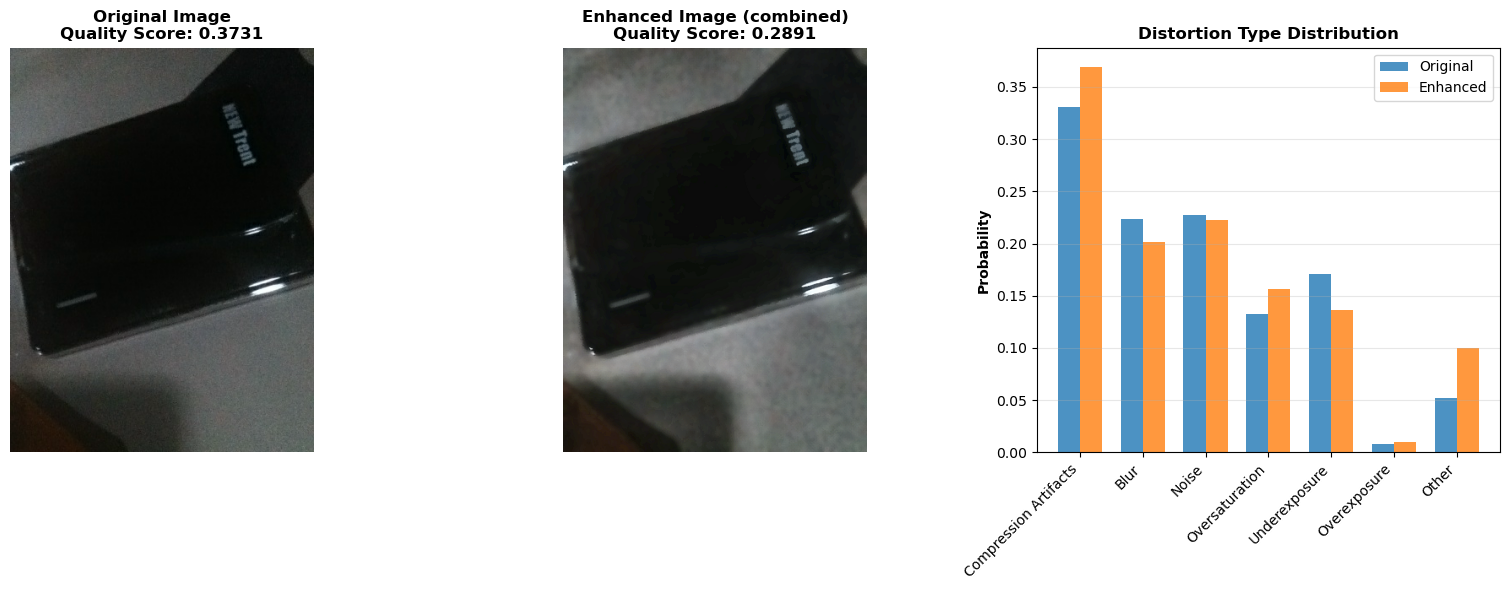


ENHANCEMENT RESULTS SUMMARY

Enhancement Method: combined
Original Quality Score: 0.373079
Enhanced Quality Score: 0.289068
Quality Improvement: -0.084011

Original Dominant Distortion: Compression Artifacts (0.3306)
Enhanced Dominant Distortion: Compression Artifacts (0.3691)

Detailed Distortion Distribution:

Original:
  Compression Artifacts: 0.330621
  Blur                : 0.223875
  Noise               : 0.227763
  Oversaturation      : 0.132842
  Underexposure       : 0.170615
  Overexposure        : 0.008176
  Other               : 0.052031

Enhanced:
  Compression Artifacts: 0.369149
  Blur                : 0.201074
  Noise               : 0.222489
  Oversaturation      : 0.156507
  Underexposure       : 0.136139
  Overexposure        : 0.010089
  Other               : 0.100089



In [ ]:
# Reload the module with NEW aggressive enhancement methods
import sys
import importlib
if 'image_enhancement' in sys.modules:
    del sys.modules['image_enhancement']
from image_enhancement import ImageEnhancer, load_and_enhance_image, save_enhanced_image
print("✅ Module reloaded with NEW aggressive enhancement methods!\n")

# Example: Process a test image
test_image = '../Dataset/Vizwiz-Data/test/test_image.jpg'  # Replace with your image path

# Check if file exists, otherwise use first available test image
if not os.path.exists(test_image):
    test_folder = '../Dataset/Vizwiz-Data/test/'
    images = [f for f in os.listdir(test_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if images:
        test_image = os.path.join(test_folder, images[0])
        print(f"Using test image: {images[0]}\n")
    else:
        print("No test images found!")
        test_image = None

if test_image and os.path.exists(test_image):
    # TRY THE NEW AGGRESSIVE METHOD - should show MAJOR improvement!
    results = assess_and_enhance_image(
        test_image,
        enhancement_method='aggressive'  # Use the NEW aggressive method!
    )
    
    visualize_results(results)

## Batch Processing: Enhance Multiple Images

In [13]:
def process_image_batch(image_folder, enhancement_method='combined', 
                       output_folder='../Dataset/enhanced_images',
                       max_images=None):
    """
    Process multiple images and save enhanced versions
    
    Args:
        image_folder: Folder containing images
        enhancement_method: Enhancement method to use
        output_folder: Where to save enhanced images
        max_images: Maximum number of images to process (None = all)
    
    Returns:
        List of results for all processed images
    """
    
    os.makedirs(output_folder, exist_ok=True)
    
    # Get list of images
    image_files = [f for f in os.listdir(image_folder) 
                   if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
    
    if max_images:
        image_files = image_files[:max_images]
    
    print(f"Processing {len(image_files)} images from {image_folder}...\n")
    
    all_results = []
    
    for idx, image_file in enumerate(image_files, 1):
        try:
            image_path = os.path.join(image_folder, image_file)
            print(f"[{idx}/{len(image_files)}] Processing {image_file}...", end=' ')
            
            # Process image
            results = assess_and_enhance_image(
                image_path,
                enhancement_method=enhancement_method,
                return_quality_details=False
            )
            
            # Save enhanced image
            output_path = os.path.join(output_folder, f'enhanced_{image_file}')
            enhanced_bgr = cv2.cvtColor(results['enhanced_image'], cv2.COLOR_RGB2BGR)
            cv2.imwrite(output_path, enhanced_bgr)
            
            all_results.append({
                'filename': image_file,
                'original_score': results['original_quality_score'],
                'enhanced_score': results['enhanced_quality_score'],
                'improvement': results['quality_improvement']
            })
            
            print(f"✓ ({results['quality_improvement']:+.4f})")
            
        except Exception as e:
            print(f"✗ Error: {str(e)}")
    
    return all_results

In [14]:
# Example: Process all test images
test_folder = '../Dataset/Vizwiz-Data/test/'

if os.path.exists(test_folder):
    batch_results = process_image_batch(
        test_folder,
        enhancement_method='combined',
        output_folder='./enhanced_test_images',
        max_images=5  # Process only first 5 images for demo
    )
    
    # Print summary statistics
    import pandas as pd
    df_results = pd.DataFrame(batch_results)
    print("\n" + "="*70)
    print("BATCH PROCESSING SUMMARY")
    print("="*70)
    print(df_results.to_string())
    print(f"\nAverage Quality Improvement: {df_results['improvement'].mean():+.6f}")
    print(f"Median Quality Improvement: {df_results['improvement'].median():+.6f}")
    print(f"Images Improved: {(df_results['improvement'] > 0).sum()} / {len(df_results)}")
else:
    print(f"Test folder not found: {test_folder}")

Processing 5 images from ../Dataset/Vizwiz-Data/test/...

[1/5] Processing VizWiz_test_00000000.jpg... Assessing quality of: ../Dataset/Vizwiz-Data/test/VizWiz_test_00000000.jpg
Original Quality Score: 0.3731
Dominant Distortion: Compression Artifacts (0.3306)

Enhancing image using 'combined' method...
Assessing quality of enhanced image...
Enhanced Quality Score: 0.2891
Enhanced Dominant Distortion: Compression Artifacts (0.3691)
Quality Improvement: -0.0840
✓ (-0.0840)
[2/5] Processing VizWiz_test_00000001.jpg... Assessing quality of: ../Dataset/Vizwiz-Data/test/VizWiz_test_00000001.jpg
Original Quality Score: 0.1266
Dominant Distortion: Compression Artifacts (0.2763)

Enhancing image using 'combined' method...
Assessing quality of enhanced image...
Enhanced Quality Score: 0.1226
Enhanced Dominant Distortion: Compression Artifacts (0.2848)
Quality Improvement: -0.0040
✓ (-0.0040)
[3/5] Processing VizWiz_test_00000002.jpg... Assessing quality of: ../Dataset/Vizwiz-Data/test/VizWiz_te

## Method Comparison: Try different enhancement methods on the same image

In [ ]:
def compare_enhancement_methods(image_path):
    """
    Compare ALL enhancement methods on a single image
    """
    methods = ['bilateral', 'nlm', 'morphological', 'adaptive', 'combined', 'aggressive']
    results_list = []
    
    print(f"Comparing ALL enhancement methods for: {image_path}\n")
    
    for method in methods:
        print(f"Processing with '{method}' method...", end=' ')
        results = assess_and_enhance_image(
            image_path,
            enhancement_method=method
        )
        results_list.append(results)
        print(f"✓")
    
    # Visualization - 2 rows, 4 columns for 7 images
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()
    
    # Original
    axes[0].imshow(results_list[0]['original_image'])
    axes[0].set_title(f"Original (BASELINE)\nScore: {results_list[0]['original_quality_score']:.4f}", 
                     fontweight='bold', fontsize=11)
    axes[0].axis('off')
    
    # Enhanced versions
    for idx, (method, results) in enumerate(zip(methods, results_list), 1):
        axes[idx].imshow(results['enhanced_image'])
        improvement = results['quality_improvement']
        color = 'green' if improvement > 0 else 'red'
        axes[idx].set_title(f"{method.upper()}\nScore: {results['enhanced_quality_score']:.4f}\nImprovement: {improvement:+.4f}",
                           fontweight='bold', fontsize=11, color=color)
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Print comparison table
    print("\n" + "="*80)
    print("ENHANCEMENT METHOD COMPARISON - ALL METHODS")
    print("="*80)
    print(f"{'Method':<15} {'Original Score':<18} {'Enhanced Score':<18} {'Improvement':<15}")
    print("-"*80)
    
    original_score = results_list[0]['original_quality_score']
    print(f"{'ORIGINAL':<15} {original_score:<18.6f}")
    
    for method, results in zip(methods, results_list):
        enhanced_score = results['enhanced_quality_score']
        improvement = results['quality_improvement']
        marker = "⭐ BEST" if improvement == max([r['quality_improvement'] for r in results_list]) else ""
        print(f"{method.upper():<15} {original_score:<18.6f} {enhanced_score:<18.6f} {improvement:+.6f} {marker}")
    
    print("="*80)
    
    return results_list

Comparing enhancement methods for: ../Dataset/Vizwiz-Data/test/VizWiz_test_00000000.jpg

Processing with 'bilateral' method... Assessing quality of: ../Dataset/Vizwiz-Data/test/VizWiz_test_00000000.jpg
Original Quality Score: 0.3731
Dominant Distortion: Compression Artifacts (0.3306)

Enhancing image using 'bilateral' method...
Assessing quality of enhanced image...
Enhanced Quality Score: 0.3329
Enhanced Dominant Distortion: Compression Artifacts (0.3865)
Quality Improvement: -0.0402
✓
Processing with 'nlm' method... Assessing quality of: ../Dataset/Vizwiz-Data/test/VizWiz_test_00000000.jpg
Original Quality Score: 0.3731
Dominant Distortion: Compression Artifacts (0.3306)

Enhancing image using 'nlm' method...
Assessing quality of enhanced image...
Enhanced Quality Score: 0.3644
Enhanced Dominant Distortion: Compression Artifacts (0.3717)
Quality Improvement: -0.0087
✓
Processing with 'morphological' method... Assessing quality of: ../Dataset/Vizwiz-Data/test/VizWiz_test_00000000.jpg


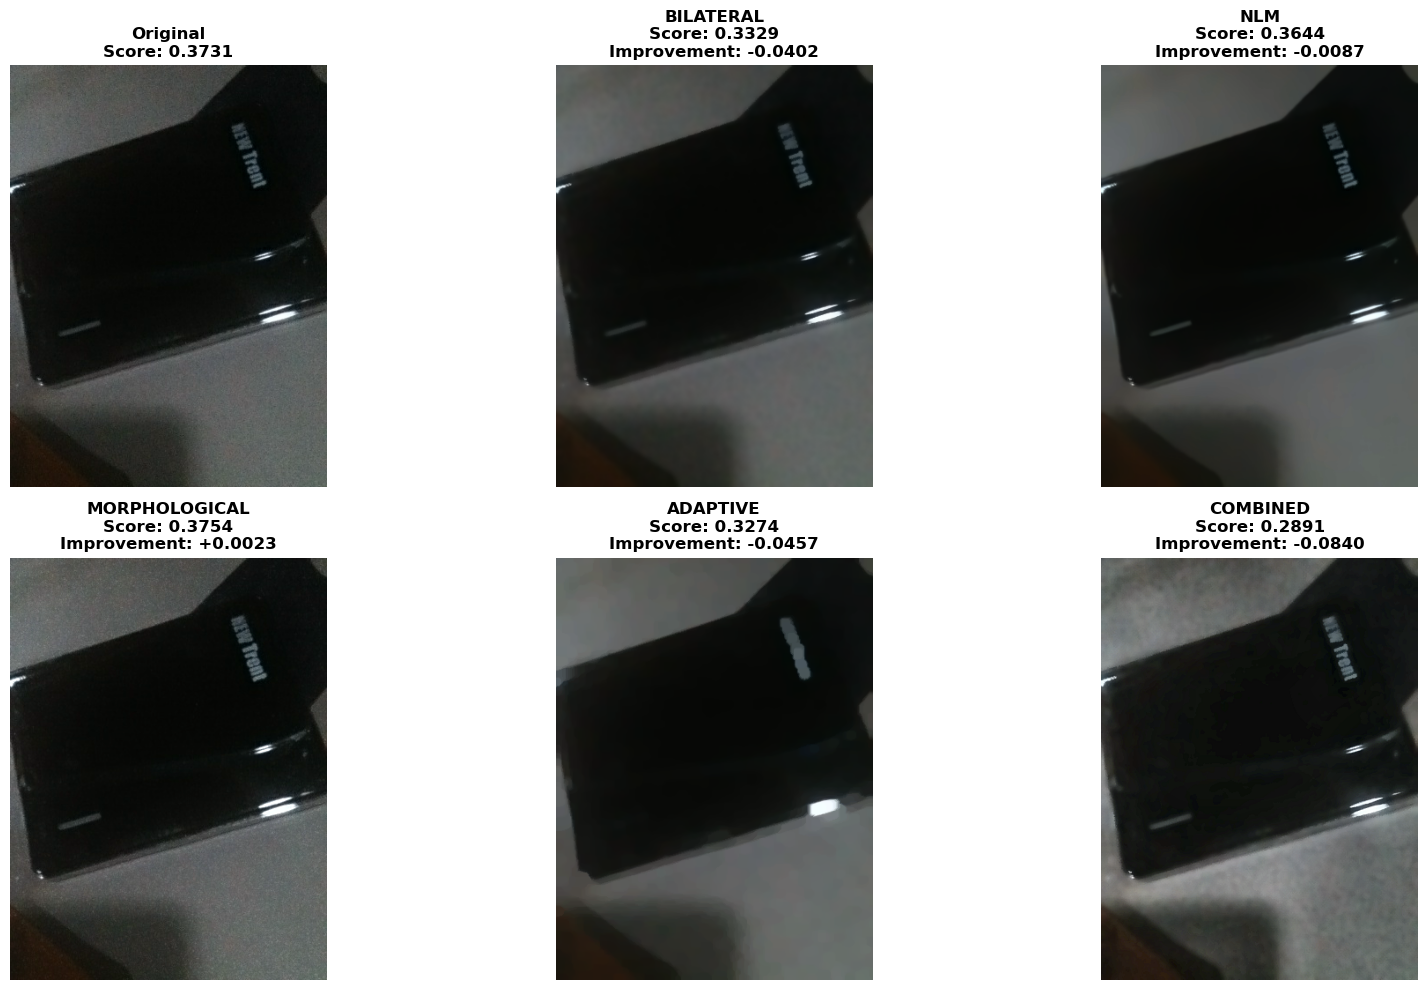


ENHANCEMENT METHOD COMPARISON
Method          Original Score     Enhanced Score     Improvement    
----------------------------------------------------------------------
ORIGINAL        0.373079          
BILATERAL       0.373079           0.332859           -0.040219
NLM             0.373079           0.364366           -0.008713
MORPHOLOGICAL   0.373079           0.375421           +0.002342
ADAPTIVE        0.373079           0.327392           -0.045687
COMBINED        0.373079           0.289068           -0.084011


In [21]:
# Example: Compare methods (uncomment to run)
if test_image and os.path.exists(test_image):
    comparison_results = compare_enhancement_methods(test_image)

In [20]:
# Reload the image_enhancement module to pick up the fix
import sys
import importlib

if 'image_enhancement' in sys.modules:
    del sys.modules['image_enhancement']

# Re-import
from image_enhancement import ImageEnhancer, load_and_enhance_image, save_enhanced_image
print("Module reloaded successfully!")


Module reloaded successfully!
